In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# NLP
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# Load dataset
df = pd.read_csv("homelessness.csv")

# Display first rows
df.head()

,Unnamed: 0,region,state,individuals,family_members,state_pop
0,0,East South Central,Alabama,2570.0,864.0,4887681
1,1,Pacific,Alaska,1434.0,582.0,735139
2,2,Mountain,Arizona,7259.0,2606.0,7158024
3,3,West South Central,Arkansas,2280.0,432.0,3009733
4,4,Pacific,California,109008.0,20964.0,39461588


In [3]:
# Check structure
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      51 non-null     int64  
 1   region          51 non-null     str    
 2   state           51 non-null     str    
 3   individuals     51 non-null     float64
 4   family_members  51 non-null     float64
 5   state_pop       51 non-null     int64  
dtypes: float64(2), int64(2), str(2)
memory usage: 3.6 KB


Unnamed: 0        0
region            0
state             0
individuals       0
family_members    0
state_pop         0
dtype: int64

In [5]:
print(df.columns.tolist())

['Unnamed: 0', 'region', 'state', 'individuals', 'family_members', 'state_pop']


In [8]:
import numpy as np
from sklearn.preprocessing import StandardScaler

features = np.array([[1, 200], [2, 300], [3, 400]])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[-1.22474487, -1.22474487],
       [ 0.        ,  0.        ],
       [ 1.22474487,  1.22474487]])

In [10]:
print(scaled_features.shape)

(3, 2)


In [12]:
print(df.shape)
print(scaled_features.shape)

(51, 6)
(3, 2)


In [14]:
print(df.columns)

Index(['Unnamed: 0', 'region', 'state', 'individuals', 'family_members',
       'state_pop'],
      dtype='str')


In [16]:
df.head()

,Unnamed: 0,region,state,individuals,family_members,state_pop
0,0,East South Central,Alabama,2570.0,864.0,4887681
1,1,Pacific,Alaska,1434.0,582.0,735139
2,2,Mountain,Arizona,7259.0,2606.0,7158024
3,3,West South Central,Arkansas,2280.0,432.0,3009733
4,4,Pacific,California,109008.0,20964.0,39461588


In [19]:
print(df.columns)

Index(['Unnamed: 0', 'region', 'state', 'individuals', 'family_members',
       'state_pop'],
      dtype='str')


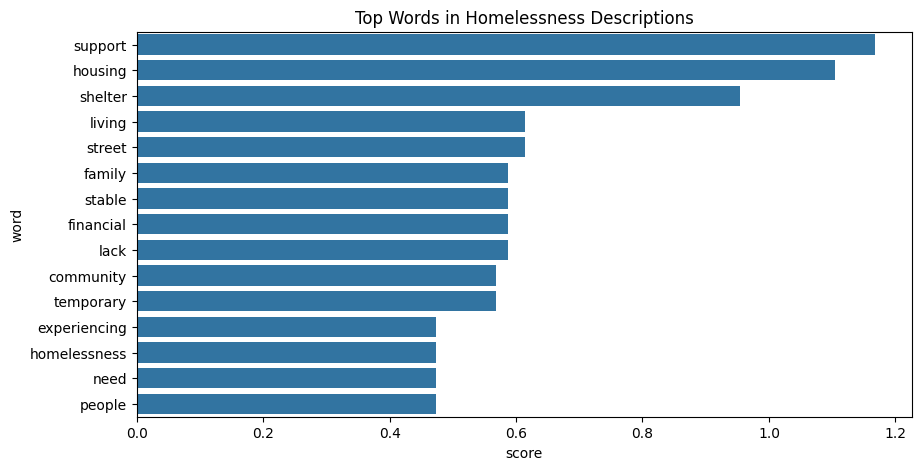

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# Example dataframe with homelessness descriptions
df = pd.DataFrame({
    'description': [
        'lack of housing and financial support',
        'living on the street without shelter',
        'no stable housing or family support',
        'temporary shelter and community support',
        'people experiencing homelessness need housing'
    ]
})

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words='english')

# Transform the text
X = vectorizer.fit_transform(df['description'])

# Get words and scores
scores = X.sum(axis=0).A1
words = vectorizer.get_feature_names_out()

# Create dataframe of top words
top_words = pd.DataFrame({
    'word': words,
    'score': scores
})

# Sort and keep top 20
top_words = top_words.sort_values(by='score', ascending=False).head(20)

# Plot
plt.figure(figsize=(10,5))

sns.barplot(
    x='score',
    y='word',
    data=top_words
)

plt.title("Top Words in Homelessness Descriptions")
plt.show()

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Convert text descriptions into TF-IDF features
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['description'])

# Apply KMeans clustering
text_kmeans = KMeans(n_clusters=3, random_state=42)

df['text_cluster'] = text_kmeans.fit_predict(tfidf_matrix)

# View results
df[['description', 'text_cluster']].head()

,description,text_cluster
0,lack of housing and financial support,2
1,living on the street without shelter,0
2,no stable housing or family support,2
3,temporary shelter and community support,0
4,people experiencing homelessness need housing,1
